In [ ]:
import torch

print("CUDA Available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

CUDA Available: True
Tesla T4


In [ ]:
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
dataset_path = "/content/drive/MyDrive/Colab Notebooks/YOLO /Face Mask/faceMask"

yaml_path = dataset_path + "/data.yaml"

print(yaml_path)

/content/drive/MyDrive/Colab Notebooks/YOLO /Face Mask/faceMask/data.yaml


In [ ]:
model = YOLO("yolo26s.pt")

In [ ]:
results = model.train(
    data=yaml_path,
    epochs=100,
    imgsz=640,
    batch=16,
    device=0,
    workers=2,

    # optimization
    optimizer="AdamW",
    lr0=0.001,

    # augmentation
    patience=20,

    # save
    project="face_mask_detection",
    name="yolo11s_mask",

    exist_ok=True
)

Ultralytics 8.4.72 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/Colab Notebooks/YOLO /Face Mask/faceMask/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo11s_mask, nbs=64, nms=False, opset=None, optimize=False,

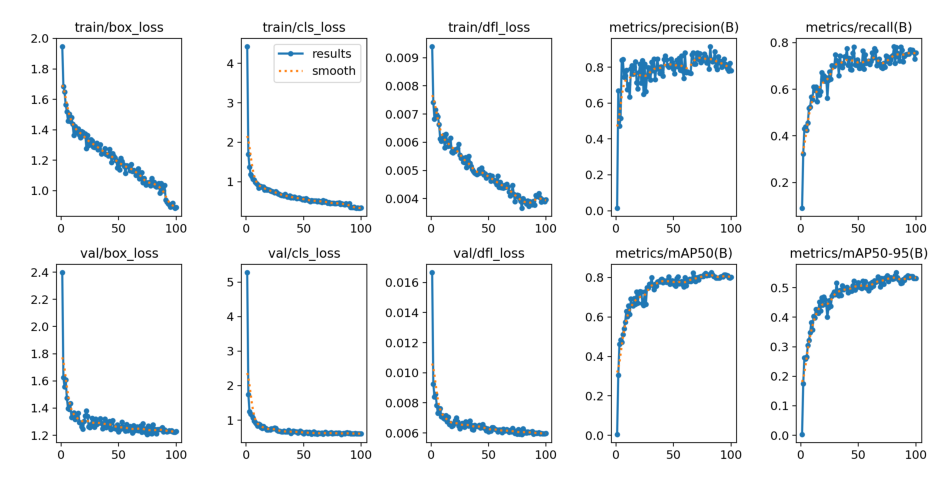

In [ ]:
import matplotlib.pyplot as plt
import cv2
import os

# Find the latest training folder
results_path = '/content/runs/detect/face_mask_detection/yolo11s_mask/results.png'

if os.path.exists(results_path):
    img = cv2.imread(results_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(12, 8))
    plt.imshow(img)
    plt.axis('off')
    plt.show()
else:
    print("Training is still in progress or path is different. Check your 'runs/detect/' directory.")

Loading model weights...

--- Evaluating Full Test Dataset ---
Ultralytics 8.4.72 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26s summary (fused): 122 layers, 9,466,341 parameters, 0 gradients, 20.5 GFLOPs
val: Fast image access ✅ (ping: 0.7±0.2 ms, read: 0.0±0.0 MB/s, size: 31.1 KB)
val: Scanning /content/drive/MyDrive/Colab Notebooks/YOLO /Face Mask/faceMask/test/labels... 85 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 85/85 1.4s/it 1:55
val: New cache created: /content/drive/MyDrive/Colab Notebooks/YOLO /Face Mask/faceMask/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 6/6 1.6it/s 3.8s
                   all         85        391      0.912      0.732      0.866      0.603
 mask_weared_incorrect          8          8          1      0.611      0.826      0.598
             with_mask         76        303      0.923      0.898      0.949      0.647
          without_mask    

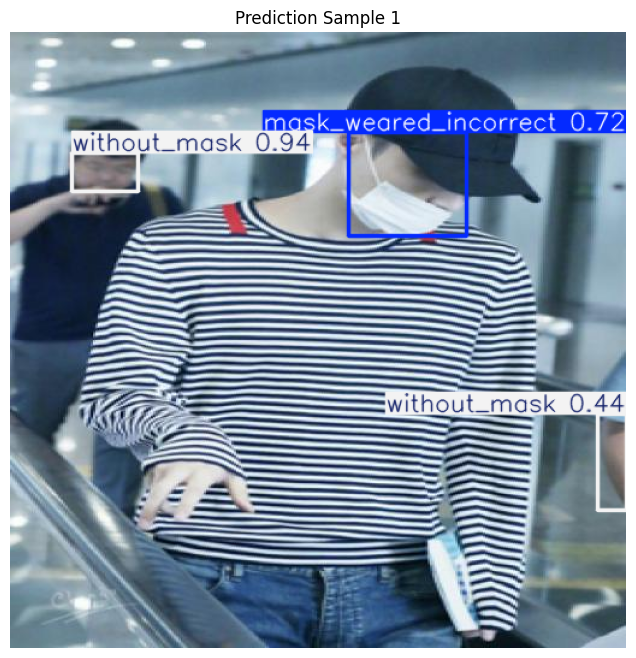


[Image 2: maksssksksss172_png.rf.d7ede5b447c3d7fba3ee79fdf66ee1bd.jpg]
  -> Detected 'without_mask' with 69.90% confidence accuracy.


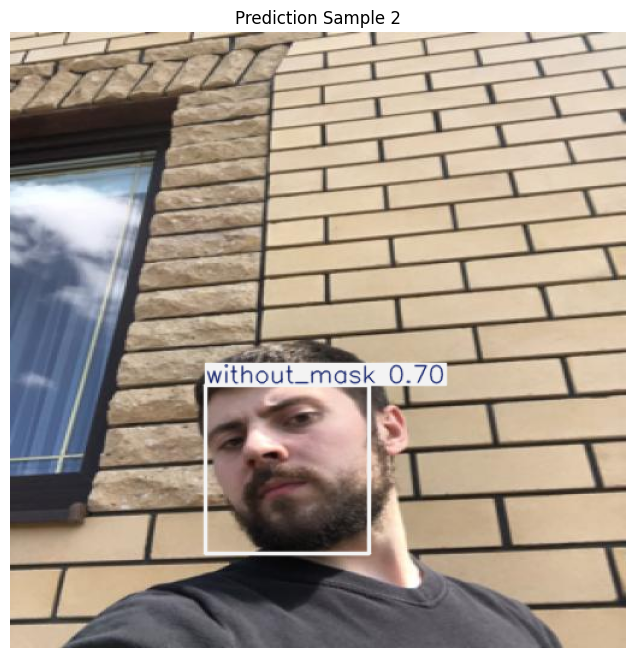


[Image 3: maksssksksss109_png.rf.53b0071fd1749a6270b733e13d7abeed.jpg]
  -> Detected 'with_mask' with 95.85% confidence accuracy.


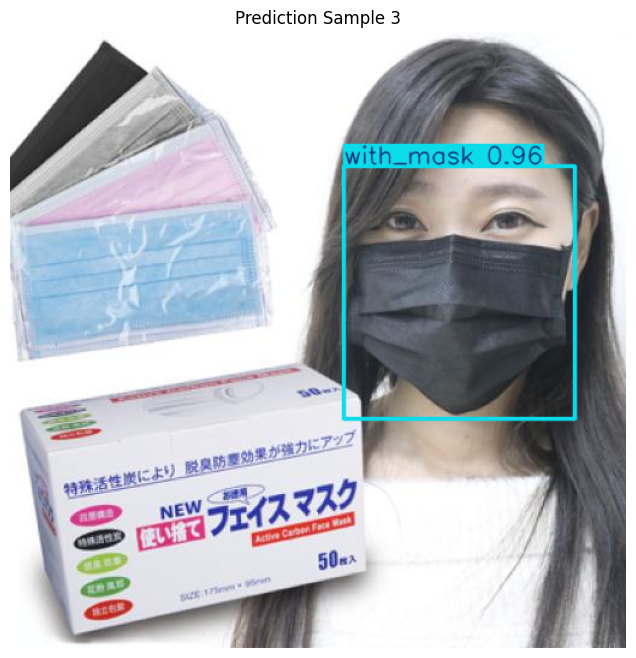

In [ ]:
import os
import glob
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO

# ==========================================
# 1. DEFINE YOUR PATHS
# ==========================================
# Paths to your trained model weights and dataset configuration
MODEL_PATH = '/content/runs/detect/face_mask_detection/yolo11s_mask/weights/best.pt'
DATA_YAML_PATH = '/content/drive/MyDrive/Colab Notebooks/YOLO /Face Mask/faceMask/data.yaml'
TEST_IMAGES_DIR = '/content/drive/MyDrive/Colab Notebooks/YOLO /Face Mask/faceMask/test/images'

# ==========================================
# 2. LOAD THE TRAINED YOLO MODEL
# ==========================================
print("Loading model weights...")
model = YOLO(MODEL_PATH)

# ==========================================
# 3. EVALUATE ON THE FULL TEST DATASET (ACCURACY)
# ==========================================
print("\n--- Evaluating Full Test Dataset ---")
# Runs validation explicitly on the test split defined in data.yaml
metrics = model.val(data=DATA_YAML_PATH, split='test')

# Display key accuracy metrics
print("\n=========================================")
print("       TEST DATASET ACCURACY METRICS     ")
print("=========================================")
print(f"Precision (B):   {metrics.results_dict['metrics/precision(B)']:.4f} (Ability to avoid false positives)")
print(f"Recall (B):      {metrics.results_dict['metrics/recall(B)']:.4f} (Ability to find all masks)")
print(f"mAP50 (B):       {metrics.results_dict['metrics/mAP50(B)']:.4f} (Mean Average Precision at IoU=0.5)")
print(f"mAP50-95 (B):    {metrics.results_dict['metrics/mAP50-95(B)']:.4f} (Overall rigorous bounding box accuracy)")
print("=========================================\n")

# ==========================================
# 4. PREDICT & VISUALIZE SAMPLE TEST IMAGES
# ==========================================
print("--- Generating Predictions on Sample Test Images ---")

# Find the first 3 images in the test folder to display as visual proof
test_images = glob.glob(os.path.join(TEST_IMAGES_DIR, "*.*"))[:3]

if not test_images:
    print(f"⚠️ No images found in {TEST_IMAGES_DIR}. Please check your path.")
else:
    for idx, img_path in enumerate(test_images):
        # Run inference on the single test image
        results = model.predict(source=img_path, conf=0.25, verbose=False)

        # Render the bounding boxes directly onto the image array
        annotated_img = results[0].plot()
        annotated_img_rgb = cv2.cvtColor(annotated_img, cv2.COLOR_BGR2RGB)

        # Print text accuracy breakdown per object detected in this image
        print(f"\n[Image {idx+1}: {os.path.basename(img_path)}]")
        boxes = results[0].boxes
        if len(boxes) == 0:
            print("  -> No faces/masks detected.")
        for box in boxes:
            cls_id = int(box.cls[0])
            label = model.names[cls_id]
            confidence = float(box.conf[0])
            print(f"  -> Detected '{label}' with {confidence:.2%} confidence accuracy.")

        # Plot and display the predicted image
        plt.figure(figsize=(8, 8))
        plt.imshow(annotated_img_rgb)
        plt.title(f"Prediction Sample {idx+1}")
        plt.axis('off')
        plt.show()

In [16]:
import os
import time
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from PIL import Image
import timm

In [17]:
DATA_DIR = '/content/drive/MyDrive/Colab Notebooks/YOLO /Face Mask/cnn_dataset'
TRAIN_DIR = os.path.join(DATA_DIR, 'train')
VAL_DIR = os.path.join(DATA_DIR, 'val')
TEST_DIR = os.path.join(DATA_DIR, 'test')

BATCH_SIZE = 32
EPOCHS = 10
LEARNING_RATE = 0.001
NUM_CLASSES = 3  # mask_weared_incorrect, with_mask, without_mask
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f"Using device: {DEVICE}")

Using device: cuda


In [18]:
train_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.RandomHorizontalFlip(),  # Augmentation to prevent overfitting
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # ImageNet defaults
])

val_test_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Loading folder datasets using ImageFolder (infers class labels from subfolder names)
train_dataset = datasets.ImageFolder(root=TRAIN_DIR, transform=train_transforms)
val_dataset = datasets.ImageFolder(root=VAL_DIR, transform=val_test_transforms)
test_dataset = datasets.ImageFolder(root=TEST_DIR, transform=val_test_transforms)

# Creating Data Loaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"Dataset summary: {len(train_dataset)} train, {len(val_dataset)} validation, {len(test_dataset)} test images.")
print(f"Mapped Classes: {train_dataset.classes}")

Dataset summary: 3257 train, 407 validation, 408 test images.
Mapped Classes: ['mask_weared_incorrect', 'with_mask', 'without_mask']


In [19]:
print("\nInitializing EfficientNet-B0...")
# Using dynamic pretrained architecture 'efficientnet_b0'
model = timm.create_model('efficientnet_b0', pretrained=True, num_classes=NUM_CLASSES)
model = model.to(DEVICE)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)


Initializing EfficientNet-B0...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

In [20]:
print("\n--- Starting Training Stage ---")
for epoch in range(EPOCHS):
    start_time = time.time()

    # --- Training State ---
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for images, labels in train_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total_train += labels.size(0)
        correct_train += predicted.eq(labels).sum().item()

    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_acc = (correct_train / total_train) * 100

    # --- Validation State ---
    model.eval()
    val_loss = 0.0
    correct_val = 0
    total_val = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            total_val += labels.size(0)
            correct_val += predicted.eq(labels).sum().item()

    epoch_val_loss = val_loss / len(val_loader.dataset)
    epoch_val_acc = (correct_val / total_val) * 100
    elapsed = time.time() - start_time

    print(f"Epoch [{epoch+1}/{EPOCHS}] ({elapsed:.1f}s) -> "
          f"Train Loss: {epoch_loss:.4f} | Train Acc: {epoch_acc:.2f}% || "
          f"Val Loss: {epoch_val_loss:.4f} | Val Acc: {epoch_val_acc:.2f}%")

# Save final weights locally
torch.save(model.state_dict(), 'efficientnet_facemask.pth')
print("\n✅ Training complete! Weights saved as 'efficientnet_facemask.pth'")


--- Starting Training Stage ---


KeyboardInterrupt: 

In [ ]:
print("\n--- Evaluating Performance on Final Test Split ---")
model.eval()
correct_test = 0
total_test = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        outputs = model(images)
        _, predicted = outputs.max(1)
        total_test += labels.size(0)
        correct_test += predicted.eq(labels).sum().item()

final_test_accuracy = (correct_test / total_test) * 100
print("=========================================")
print(f" FINAL TEST SPLIT GLOBAL ACCURACY: {final_test_accuracy:.2f}%")
print("=========================================")

In [21]:
import os
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader

from tqdm import tqdm
import matplotlib.pyplot as plt

from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

In [23]:
DATA_DIR = "/content/drive/MyDrive/YOLO /Face Mask/cnn_dataset"


TRAIN_DIR = os.path.join(DATA_DIR,"train")
VAL_DIR   = os.path.join(DATA_DIR,"val")
TEST_DIR  = os.path.join(DATA_DIR,"test")


IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 5

LR = 1e-4


DEVICE = "cuda" if torch.cuda.is_available() else "cpu"


print("Device:",DEVICE)

Device: cuda


In [27]:
train_transform = transforms.Compose([

    transforms.Resize(
        (IMG_SIZE,IMG_SIZE)
    ),

    transforms.RandomHorizontalFlip(),

    transforms.RandomRotation(10),

    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])



test_transform = transforms.Compose([

    transforms.Resize(
        (IMG_SIZE,IMG_SIZE)
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

In [ ]:
import os
import time
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import timm

# =====================================================================
# 1. SETUP CONFIGURATIONS & EXACT PATHS
# =====================================================================
# This matches your exact Drive layout including the spaces around "YOLO "
DATA_DIR = '/content/drive/MyDrive/Colab Notebooks/YOLO /Face Mask/cnn_dataset'

TRAIN_DIR = os.path.join(DATA_DIR, 'train')
VAL_DIR = os.path.join(DATA_DIR, 'val')
TEST_DIR = os.path.join(DATA_DIR, 'test')

BATCH_SIZE = 32
EPOCHS = 3
LEARNING_RATE = 0.001
IMG_SIZE = 224  # Standard default input size expected by EfficientNet-B0
NUM_CLASSES = 3
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f"Using device: {DEVICE}")
print(f"Targeting training root: {TRAIN_DIR}")

# =====================================================================
# 2. DATA TRANSFORMATIONS (OPTIMIZED FOR TINY IMAGES)
# =====================================================================
# We use Nearest Neighbor interpolation to stop small pixel blocks from blurring out
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE), interpolation=transforms.InterpolationMode.NEAREST),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE), interpolation=transforms.InterpolationMode.NEAREST),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Loading datasets safely via ImageFolder
print("\nLoading dataset directories...")
train_dataset = datasets.ImageFolder(root=TRAIN_DIR, transform=train_transform)
val_dataset = datasets.ImageFolder(root=VAL_DIR, transform=test_transform)
test_dataset = datasets.ImageFolder(root=TEST_DIR, transform=test_transform)

# Optimized DataLoaders with high worker throughput and pinned memory
train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=4, pin_memory=True, drop_last=True
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=4, pin_memory=True
)
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=4, pin_memory=True
)

print(f"✅ Loaders ready!")
print(f"Dataset sizes -> Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")
print(f"Mapped Classes dynamically: {train_dataset.classes}")

# =====================================================================
# 3. INITIALIZE MODEL & OPTIMIZER
# =====================================================================
print("\nInitializing EfficientNet-B0...")
model = timm.create_model('efficientnet_b0', pretrained=True, num_classes=NUM_CLASSES)
model = model.to(DEVICE)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

# =====================================================================
# 4. TRAINING & VALIDATION LOOPS
# =====================================================================
print("\n--- Starting Training Stage ---")
for epoch in range(EPOCHS):
    start_time = time.time()

    # --- Training Phase ---
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for images, labels in train_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total_train += labels.size(0)
        correct_train += predicted.eq(labels).sum().item()

    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_acc = (correct_train / total_train) * 100

    # --- Validation Phase ---
    model.eval()
    val_loss = 0.0
    correct_val = 0
    total_val = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            total_val += labels.size(0)
            correct_val += predicted.eq(labels).sum().item()

    epoch_val_loss = val_loss / len(val_loader.dataset)
    epoch_val_acc = (correct_val / total_val) * 100
    elapsed = time.time() - start_time

    print(f"Epoch [{epoch+1}/{EPOCHS}] ({elapsed:.1f}s) -> "
          f"Train Loss: {epoch_loss:.4f} | Train Acc: {epoch_acc:.2f}% || "
          f"Val Loss: {epoch_val_loss:.4f} | Val Acc: {epoch_val_acc:.2f}%")

# Save weights locally
torch.save(model.state_dict(), 'efficientnet_facemask.pth')
print("\n✅ Training complete! Model weights saved as 'efficientnet_facemask.pth'")

# =====================================================================
# 5. TEST SPLIT PERFORMANCE SUMMARY
# =====================================================================
print("\n--- Evaluating Performance on Final Test Split ---")
model.eval()
correct_test = 0
total_test = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        outputs = model(images)
        _, predicted = outputs.max(1)
        total_test += labels.size(0)
        correct_test += predicted.eq(labels).sum().item()

final_test_accuracy = (correct_test / total_test) * 100
print("=========================================")
print(f" FINAL TEST SPLIT GLOBAL ACCURACY: {final_test_accuracy:.2f}%")
print("=========================================")

Using device: cuda
Targeting training root: /content/drive/MyDrive/Colab Notebooks/YOLO /Face Mask/cnn_dataset/train

Loading dataset directories...


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


✅ Loaders ready!
Dataset sizes -> Train: 3257 | Val: 407 | Test: 408
Mapped Classes dynamically: ['mask_weared_incorrect', 'with_mask', 'without_mask']

Initializing EfficientNet-B0...

--- Starting Training Stage ---


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
